# Abu Dhabi 2021 GP - The Championship Finale Analysis
# This notebook explores one of the most controversial races in F1 history

In [2]:
#Import Libraries and Setup
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"FastF1 version: {fastf1.__version__}")

✅ All libraries imported successfully!
FastF1 version: 3.6.1


# ============================================================================
# LOAD ABU DHABI 2021 RACE DATA
# ============================================================================

In [4]:
# Load the race session
session = fastf1.get_session(2021, 'Abu Dhabi', 'R')
print("Loading session data... (this may take 30-60 seconds first time)")
session.load()

print("\n✅ Session loaded successfully!")
print(f"Event: {session.event['EventName']}")
print(f"Date: {session.event['EventDate']}")
print(f"Circuit: {session.event['Location']}")

req         WARNING 	DEFAULT CACHE ENABLED! (641.83 MB) C:\Users\User\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading session data... (this may take 30-60 seconds first time)


core        WARNING 	No lap data for driver 9
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 9)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 33 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['33', '44', '55', '22', '10', '77', '4', '14', '31', '16', '5', '3', '18', '47', '11', '6', '99', '63', '7', '9']



✅ Session loaded successfully!
Event: Abu Dhabi Grand Prix
Date: 2021-12-12 00:00:00
Circuit: Yas Island


In [5]:
# Get All Laps Data

# %%
laps = session.laps
print(f"Total laps recorded: {len(laps)}")
print(f"Drivers in the race: {sorted(laps['Driver'].unique())}")

# Display first few laps
print("\n📊 Sample Lap Data:")
laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Team']].head(10)

Total laps recorded: 1000
Drivers in the race: ['ALO', 'BOT', 'GAS', 'GIO', 'HAM', 'LAT', 'LEC', 'MSC', 'NOR', 'OCO', 'PER', 'RAI', 'RIC', 'RUS', 'SAI', 'STR', 'TSU', 'VER', 'VET']

📊 Sample Lap Data:


,Driver,LapNumber,LapTime,Compound,TyreLife,Team
0,GAS,1.0,0 days 00:01:39.330000,HARD,1.0,AlphaTauri
1,GAS,2.0,0 days 00:01:32.814000,HARD,2.0,AlphaTauri
2,GAS,3.0,0 days 00:01:31.533000,HARD,3.0,AlphaTauri
3,GAS,4.0,0 days 00:01:31.439000,HARD,4.0,AlphaTauri
4,GAS,5.0,0 days 00:01:31.367000,HARD,5.0,AlphaTauri
5,GAS,6.0,0 days 00:01:30.786000,HARD,6.0,AlphaTauri
6,GAS,7.0,0 days 00:01:30.757000,HARD,7.0,AlphaTauri
7,GAS,8.0,0 days 00:01:31.135000,HARD,8.0,AlphaTauri
8,GAS,9.0,0 days 00:01:31.365000,HARD,9.0,AlphaTauri
9,GAS,10.0,0 days 00:01:30.880000,HARD,10.0,AlphaTauri


In [6]:
# Focus on Verstappen vs Hamilton
# Filter laps for VER and HAM
ver_laps = laps.pick_driver('VER')
ham_laps = laps.pick_driver('HAM')

print(f"Verstappen Total Laps: {len(ver_laps)}")
print(f"Hamilton Total Laps: {len(ham_laps)}")

# Convert lap times to seconds for analysis
ver_laps = ver_laps.copy()
ham_laps = ham_laps.copy()
ver_laps['LapTime_sec'] = ver_laps['LapTime'].dt.total_seconds()
ham_laps['LapTime_sec'] = ham_laps['LapTime'].dt.total_seconds()

Verstappen Total Laps: 58
Hamilton Total Laps: 58


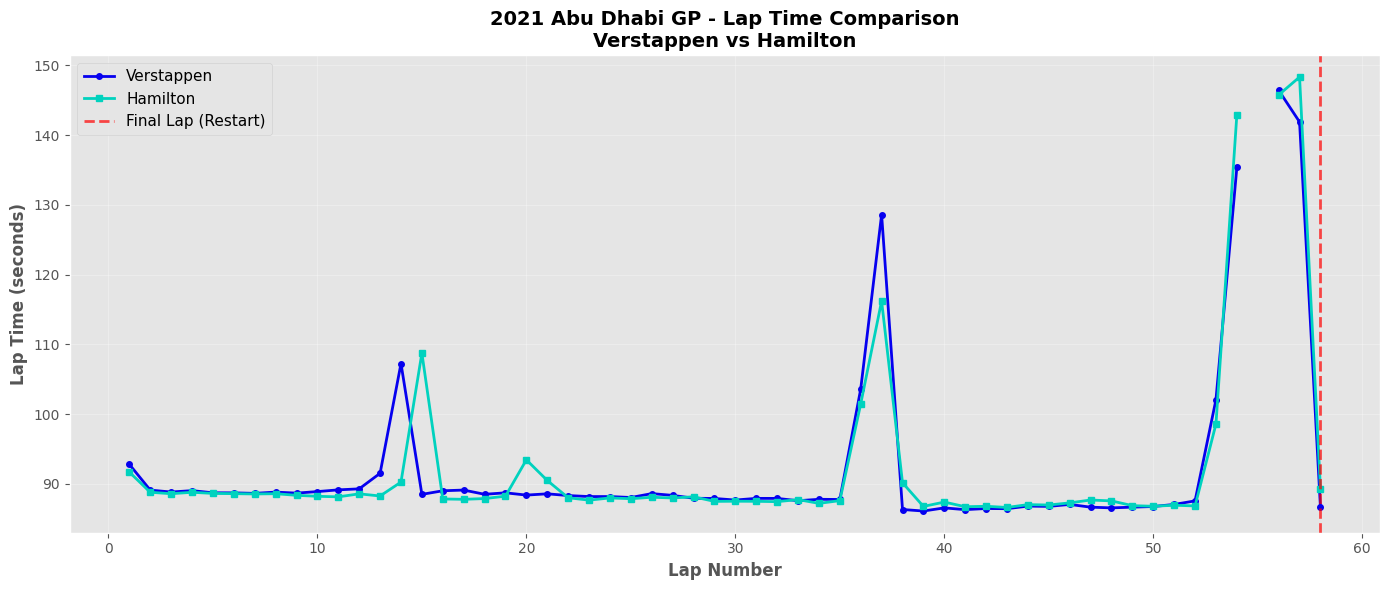

In [7]:
# Step 5: Lap Time Comparison Throughout the Race
fig, ax = plt.subplots(figsize=(14, 6))

# Plot lap times
ax.plot(ver_laps['LapNumber'], ver_laps['LapTime_sec'], 
        marker='o', linewidth=2, markersize=4, label='Verstappen', color='#0600EF')
ax.plot(ham_laps['LapNumber'], ham_laps['LapTime_sec'], 
        marker='s', linewidth=2, markersize=4, label='Hamilton', color='#00D2BE')

# Highlight the final lap (lap 58 - the controversial restart)
ax.axvline(x=58, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Final Lap (Restart)')

ax.set_xlabel('Lap Number', fontsize=12, fontweight='bold')
ax.set_ylabel('Lap Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('2021 Abu Dhabi GP - Lap Time Comparison\nVerstappen vs Hamilton', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

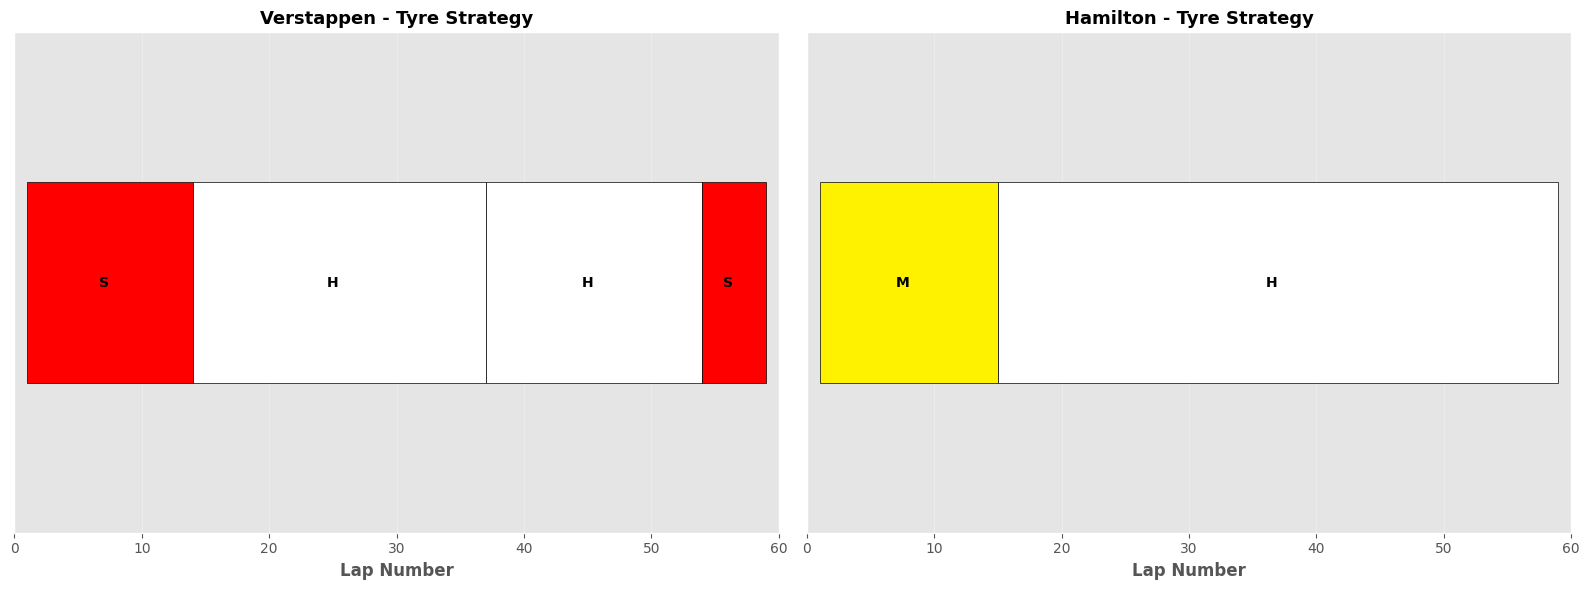


📊 Pit Stop Summary:
Verstappen Pit Stops: 4.0
Hamilton Pit Stops: 2.0


In [8]:
# Tyre Strategy Analysis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Verstappen's tyre strategy
ver_stints = ver_laps.groupby(['Stint', 'Compound']).agg({
    'LapNumber': ['min', 'max', 'count']
}).reset_index()

for idx, row in ver_stints.iterrows():
    compound = row[('Compound', '')]
    start_lap = row[('LapNumber', 'min')]
    end_lap = row[('LapNumber', 'max')]
    
    color_map = {'SOFT': '#FF0000', 'MEDIUM': '#FFF200', 'HARD': '#FFFFFF'}
    color = color_map.get(compound, 'gray')
    
    ax1.barh(0, end_lap - start_lap + 1, left=start_lap, height=0.4, 
             color=color, edgecolor='black', label=compound if idx == 0 else "")
    ax1.text((start_lap + end_lap) / 2, 0, compound[0], 
             ha='center', va='center', fontweight='bold', fontsize=10)

ax1.set_xlim(0, 60)
ax1.set_ylim(-0.5, 0.5)
ax1.set_xlabel('Lap Number', fontsize=12, fontweight='bold')
ax1.set_title('Verstappen - Tyre Strategy', fontsize=13, fontweight='bold')
ax1.set_yticks([])
ax1.grid(True, axis='x', alpha=0.3)


# Hamilton's tyre strategy
ham_stints = ham_laps.groupby(['Stint', 'Compound']).agg({
    'LapNumber': ['min', 'max', 'count']
}).reset_index()

for idx, row in ham_stints.iterrows():
    compound = row[('Compound', '')]
    start_lap = row[('LapNumber', 'min')]
    end_lap = row[('LapNumber', 'max')]
    
    color_map = {'SOFT': '#FF0000', 'MEDIUM': '#FFF200', 'HARD': '#FFFFFF'}
    color = color_map.get(compound, 'gray')
    
    ax2.barh(0, end_lap - start_lap + 1, left=start_lap, height=0.4, 
             color=color, edgecolor='black', label=compound if idx == 0 else "")
    ax2.text((start_lap + end_lap) / 2, 0, compound[0], 
             ha='center', va='center', fontweight='bold', fontsize=10)

ax2.set_xlim(0, 60)
ax2.set_ylim(-0.5, 0.5)
ax2.set_xlabel('Lap Number', fontsize=12, fontweight='bold')
ax2.set_title('Hamilton - Tyre Strategy', fontsize=13, fontweight='bold')
ax2.set_yticks([])
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Pit Stop Summary:")
print(f"Verstappen Pit Stops: {ver_laps['Stint'].max()}")
print(f"Hamilton Pit Stops: {ham_laps['Stint'].max()}")

In [9]:
# Speed Comparison - Fastest Laps Telemetry

# %%
# Get fastest laps
ver_fastest = ver_laps.pick_fastest()
ham_fastest = ham_laps.pick_fastest()

print(f"Verstappen Fastest Lap: Lap {ver_fastest['LapNumber']} - {ver_fastest['LapTime']}")
print(f"Hamilton Fastest Lap: Lap {ham_fastest['LapNumber']} - {ham_fastest['LapTime']}")

# Get telemetry data
ver_tel = ver_fastest.get_telemetry().add_distance()
ham_tel = ham_fastest.get_telemetry().add_distance()

Verstappen Fastest Lap: Lap 39.0 - 0 days 00:01:26.103000
Hamilton Fastest Lap: Lap 43.0 - 0 days 00:01:26.615000


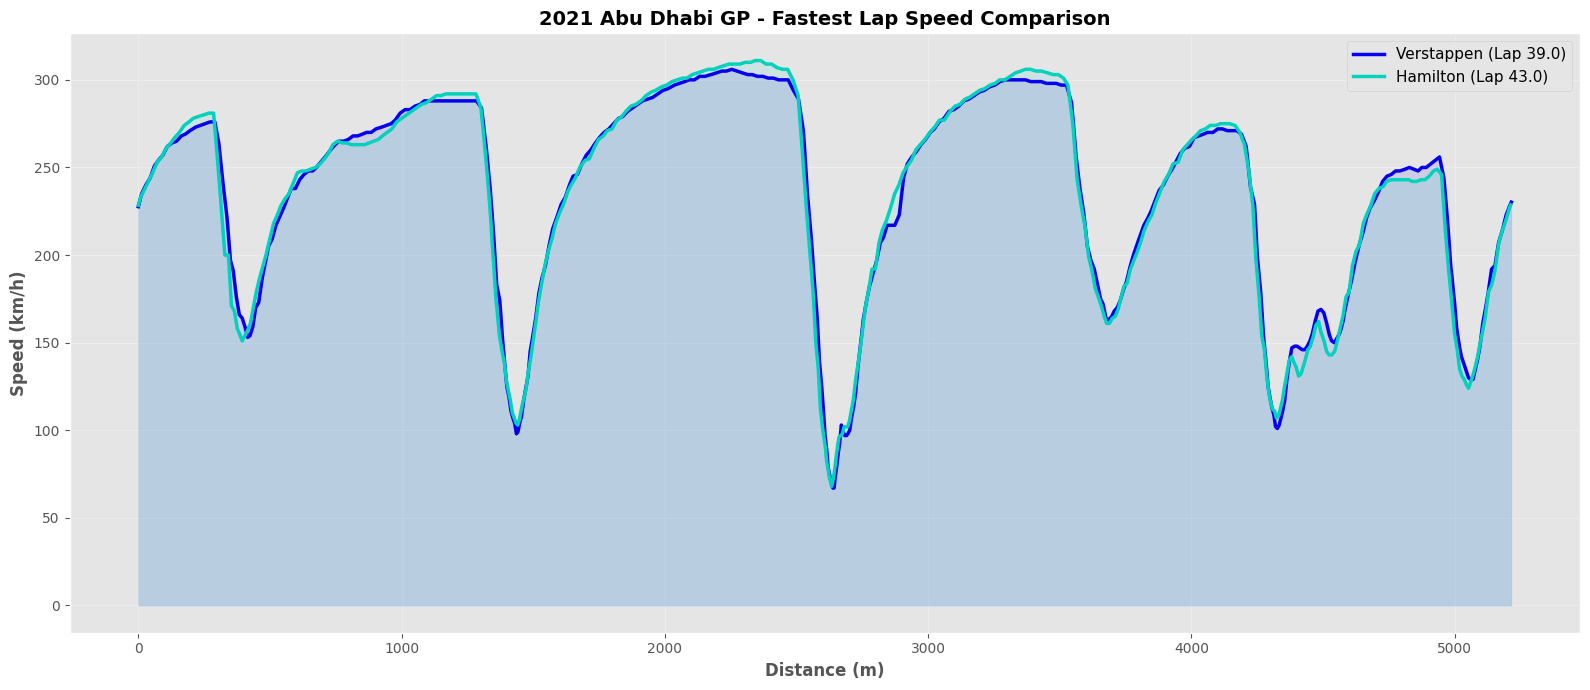

In [10]:
# Speed Trace Visualization

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(ver_tel['Distance'], ver_tel['Speed'], 
        label=f'Verstappen (Lap {ver_fastest["LapNumber"]})', 
        color='#0600EF', linewidth=2.5)
ax.plot(ham_tel['Distance'], ham_tel['Speed'], 
        label=f'Hamilton (Lap {ham_fastest["LapNumber"]})', 
        color='#00D2BE', linewidth=2.5)

ax.set_xlabel('Distance (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold')
ax.set_title('2021 Abu Dhabi GP - Fastest Lap Speed Comparison', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.fill_between(ver_tel['Distance'], 0, ver_tel['Speed'], alpha=0.1, color='#0600EF')
ax.fill_between(ham_tel['Distance'], 0, ham_tel['Speed'], alpha=0.1, color='#00D2BE')

plt.tight_layout()
plt.show()

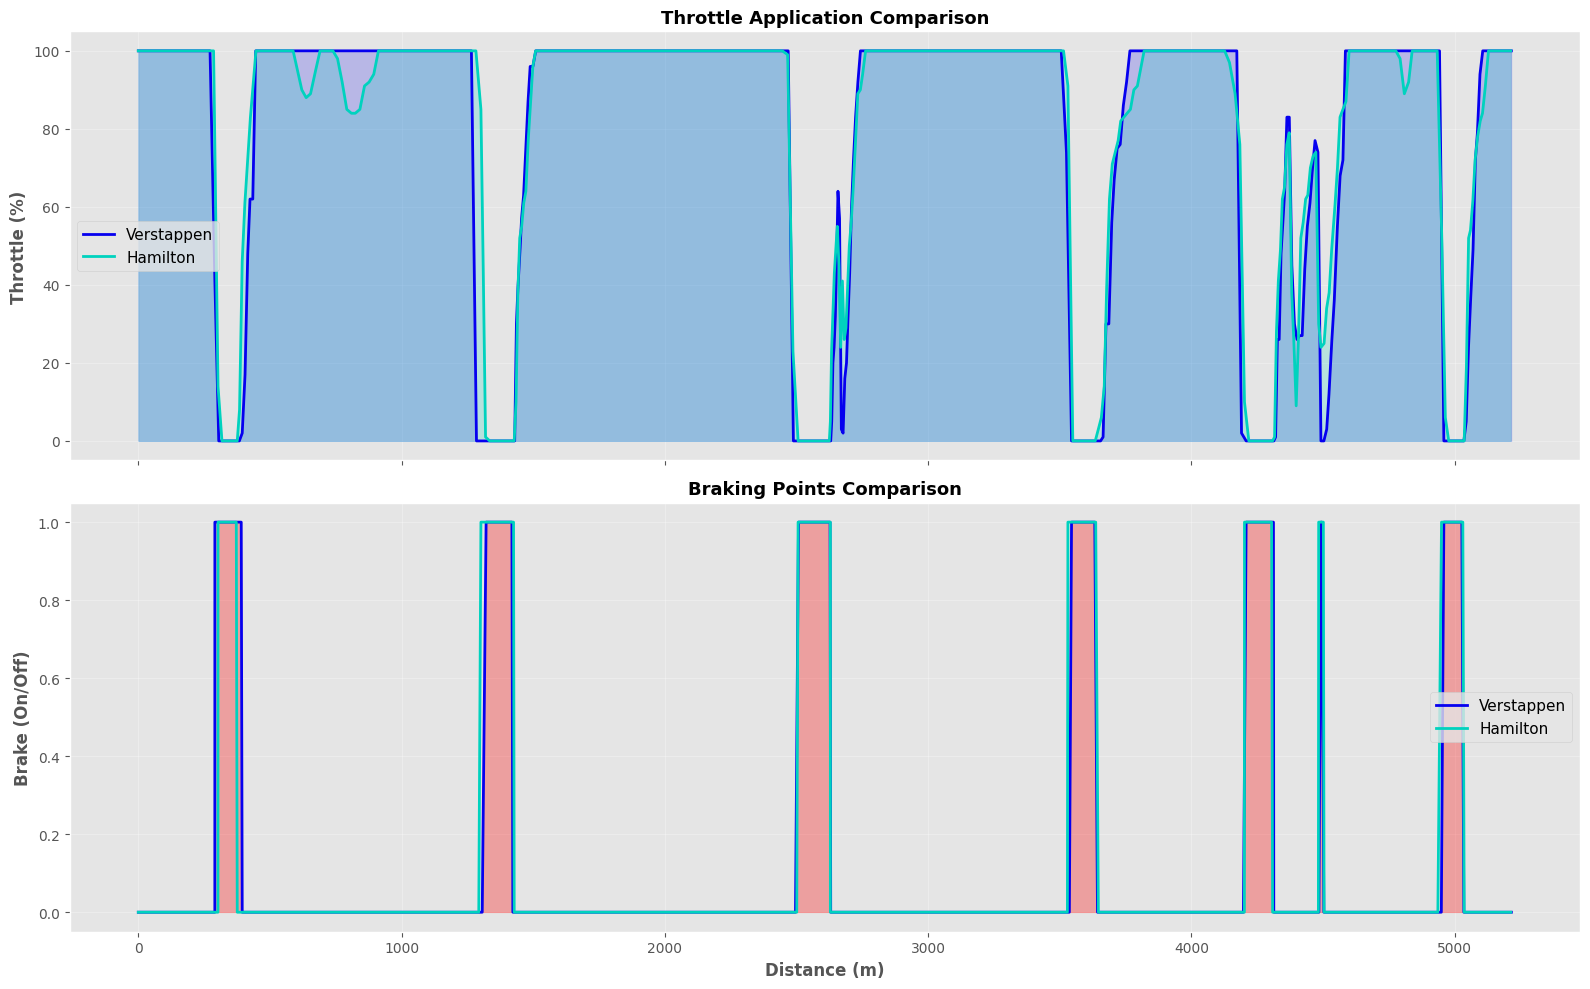

In [11]:
#  Throttle and Brake Analysis

# %%
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Throttle comparison
ax1.plot(ver_tel['Distance'], ver_tel['Throttle'], 
         label='Verstappen', color='#0600EF', linewidth=2)
ax1.plot(ham_tel['Distance'], ham_tel['Throttle'], 
         label='Hamilton', color='#00D2BE', linewidth=2)
ax1.set_ylabel('Throttle (%)', fontsize=12, fontweight='bold')
ax1.set_title('Throttle Application Comparison', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.fill_between(ver_tel['Distance'], 0, ver_tel['Throttle'], alpha=0.2, color='#0600EF')
ax1.fill_between(ham_tel['Distance'], 0, ham_tel['Throttle'], alpha=0.2, color='#00D2BE')

# Brake comparison
ax2.plot(ver_tel['Distance'], ver_tel['Brake'], 
         label='Verstappen', color='#0600EF', linewidth=2)
ax2.plot(ham_tel['Distance'], ham_tel['Brake'], 
         label='Hamilton', color='#00D2BE', linewidth=2)
ax2.set_xlabel('Distance (m)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Brake (On/Off)', fontsize=12, fontweight='bold')
ax2.set_title('Braking Points Comparison', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.fill_between(ver_tel['Distance'], 0, ver_tel['Brake'], alpha=0.3, color='red')

plt.tight_layout()
plt.show()


In [12]:
# Summary Statistics

print("=" * 60)
print("📊 2021 ABU DHABI GP - RACE STATISTICS")
print("=" * 60)

# Average lap times (excluding outliers)
ver_avg = ver_laps[ver_laps['LapTime_sec'] < 100]['LapTime_sec'].mean()
ham_avg = ham_laps[ham_laps['LapTime_sec'] < 100]['LapTime_sec'].mean()

print(f"\n⏱️  Average Lap Time:")
print(f"   Verstappen: {ver_avg:.3f}s")
print(f"   Hamilton:   {ham_avg:.3f}s")
print(f"   Difference: {abs(ver_avg - ham_avg):.3f}s")

# Fastest laps
print(f"\n🏁 Fastest Lap:")
print(f"   Verstappen: {ver_laps['LapTime_sec'].min():.3f}s (Lap {ver_laps.loc[ver_laps['LapTime_sec'].idxmin(), 'LapNumber']})")
print(f"   Hamilton:   {ham_laps['LapTime_sec'].min():.3f}s (Lap {ham_laps.loc[ham_laps['LapTime_sec'].idxmin(), 'LapNumber']})")

# Top speed
print(f"\n🚀 Top Speed:")
print(f"   Verstappen: {ver_tel['Speed'].max():.1f} km/h")
print(f"   Hamilton:   {ham_tel['Speed'].max():.1f} km/h")

print("\n" + "=" * 60)
print("🏆 RACE RESULT: Max Verstappen - World Champion!")
print("=" * 60)


📊 2021 ABU DHABI GP - RACE STATISTICS

⏱️  Average Lap Time:
   Verstappen: 88.034s
   Hamilton:   88.315s
   Difference: 0.282s

🏁 Fastest Lap:
   Verstappen: 86.103s (Lap 39.0)
   Hamilton:   86.615s (Lap 43.0)

🚀 Top Speed:
   Verstappen: 306.0 km/h
   Hamilton:   311.0 km/h

🏆 RACE RESULT: Max Verstappen - World Champion!


In [42]:
# Official Race Results Table (Styled)

import pandas as pd
from IPython.display import display, HTML

# Get race results
results = session.results

# Prepare data
results_table = pd.DataFrame({
    'Pos': pd.to_numeric(results['Position'], errors='coerce').fillna(0).astype(int),
    'Driver': results['Abbreviation'],
    'Team': results['TeamName'],
    'Grid': pd.to_numeric(results['GridPosition'], errors='coerce').fillna(0).astype(int),
    'Points': pd.to_numeric(results['Points'], errors='coerce').fillna(0).astype(int),
    'Laps': results['Position'].apply(lambda x: 58 if x <= 13 else '57' if x <= 14 else '+1 Lap' if x <= 15 else 'DNF'),
    'Time': results['Time'].apply(lambda x: str(x) if pd.notna(x) else ''),
    'Status': results['Status']
})

# Sort by position
results_table = results_table.sort_values('Pos').reset_index(drop=True)

# Style the table
def highlight_podium(row):
    if row['Pos'] == 1:
        return ['background-color: #FFD700'] * len(row)  # Gold
    elif row['Pos'] == 2:
        return ['background-color: #C0C0C0'] * len(row)  # Silver
    elif row['Pos'] == 3:
        return ['background-color: #CD7F32'] * len(row)  # Bronze
    return [''] * len(row)

styled_table = results_table.style.apply(highlight_podium, axis=1)\
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt',
        'border': '1px solid black'
    })\
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', "#000000"),
            ('color', 'white'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('font-size', '12pt')
        ]}
    ])\
    .hide(axis='index')

print("🏁 2021 ABU DHABI GRAND PRIX - FINAL CLASSIFICATION\n")
display(styled_table)

# Additional stats
print("\n" + "=" * 70)
print("📊 RACE STATISTICS:")
print("=" * 70)
print(f"✅ Finishers: {len(results_table[results_table['Status'] == 'Finished'])}/20")
print(f"🔧 Retirements: {len(results_table[results_table['Status'] != 'Finished'])}")
print(f"🏎️ Lapped Cars: {len(results_table[results_table['Laps'].astype(str).str.contains('Lap', na=False)])}")
print(f"🏆 Points Scored: {results_table['Points'].sum()} total points awarded")
print("=" * 70)

🏁 2021 ABU DHABI GRAND PRIX - FINAL CLASSIFICATION



Pos,Driver,Team,Grid,Points,Laps,Time,Status
0,MAZ,Haas F1 Team,0,0,DNF,,Illness
1,VER,Red Bull Racing,1,26,58,0 days 01:30:17.345000,Finished
2,HAM,Mercedes,2,18,58,0 days 00:00:02.256000,Finished
3,SAI,Ferrari,5,15,58,0 days 00:00:05.173000,Finished
4,TSU,AlphaTauri,8,12,58,0 days 00:00:05.692000,Finished
5,GAS,AlphaTauri,12,10,58,0 days 00:00:06.531000,Finished
6,BOT,Mercedes,6,8,58,0 days 00:00:07.463000,Finished
7,NOR,McLaren,3,6,58,0 days 00:00:59.200000,Finished
8,ALO,Alpine,11,4,58,0 days 00:01:01.708000,Finished
9,OCO,Alpine,9,2,58,0 days 00:01:04.026000,Finished



📊 RACE STATISTICS:
✅ Finishers: 11/20
🔧 Retirements: 9
🏎️ Lapped Cars: 1
🏆 Points Scored: 102 total points awarded


In [28]:
# Fastest Lap Analysis

# Find the fastest lap in the race
all_laps = session.laps
valid_laps = all_laps[all_laps['LapTime'].dt.total_seconds() < 200]

fastest_lap_idx = valid_laps['LapTime'].idxmin()
fastest_lap_info = valid_laps.loc[fastest_lap_idx]

print("⏱️  FASTEST LAP OF THE RACE")
print("=" * 50)
print(f"Driver:      {fastest_lap_info['Driver']}")
print(f"Lap Number:  {fastest_lap_info['LapNumber']}")
print(f"Lap Time:    {fastest_lap_info['LapTime']}")
print(f"Compound:    {fastest_lap_info['Compound']}")
print(f"Team:        {fastest_lap_info['Team']}")
print("=" * 50)

# Top 5 fastest laps
print("\n🔥 TOP 5 FASTEST LAPS:")
print("=" * 50)
top_5_laps = valid_laps.nsmallest(5, 'LapTime')[
    ['Driver', 'LapNumber', 'LapTime', 'Compound']
]
print(top_5_laps.to_string(index=False))
print("=" * 50)

⏱️  FASTEST LAP OF THE RACE
Driver:      VER
Lap Number:  39.0
Lap Time:    0 days 00:01:26.103000
Compound:    HARD
Team:        Red Bull Racing

🔥 TOP 5 FASTEST LAPS:
Driver  LapNumber                LapTime Compound
   VER       39.0 0 days 00:01:26.103000     HARD
   VER       41.0 0 days 00:01:26.301000     HARD
   VER       38.0 0 days 00:01:26.321000     HARD
   PER       51.0 0 days 00:01:26.419000     HARD
   PER       50.0 0 days 00:01:26.428000     HARD


🏆 2021 FORMULA 1 WORLD CHAMPIONSHIP - FINAL STANDINGS
 Position           Driver       Team  Points
        1   Max Verstappen   Red Bull   395.5
        2   Lewis Hamilton   Mercedes   387.5
        3  Valtteri Bottas   Mercedes   226.0
        4     Sergio Perez   Red Bull   190.0
        5     Carlos Sainz    Ferrari   164.5
        6     Lando Norris    McLaren   160.0
        7  Charles Leclerc    Ferrari   159.0
        8 Daniel Ricciardo    McLaren   115.0
        9     Pierre Gasly AlphaTauri   110.0
       10  Fernando Alonso     Alpine    81.0

🎉 WORLD CHAMPION: Max Verstappen
   Final Margin: 8.0 points
   First Championship Title! 🥇


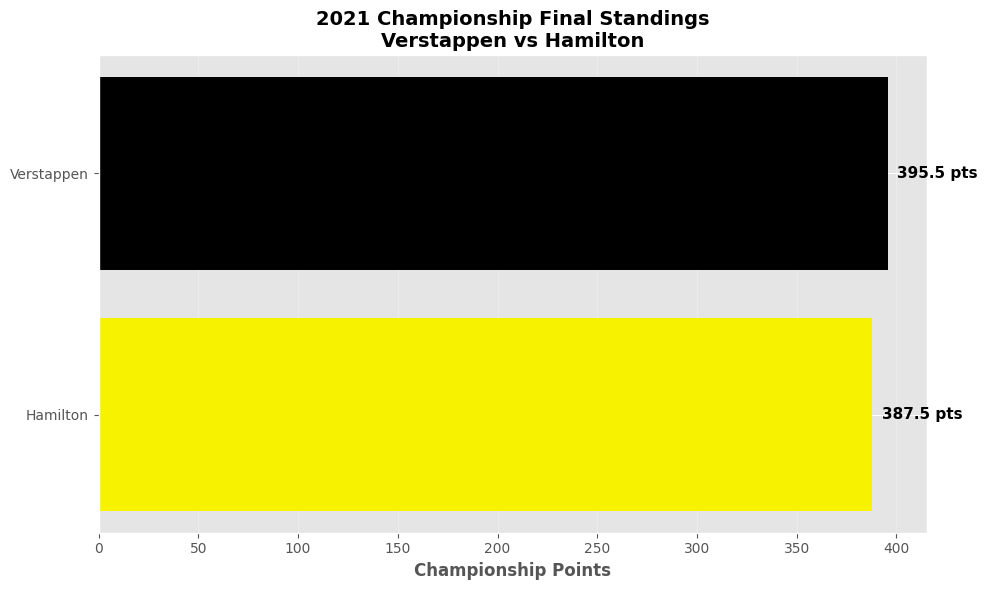

In [44]:
# 2021 Championship Final Standings

# Championship standings after Abu Dhabi (manual entry based on historical data)
championship_data = {
    'Position': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Driver': ['Max Verstappen', 'Lewis Hamilton', 'Valtteri Bottas', 
               'Sergio Perez', 'Carlos Sainz', 'Lando Norris',
               'Charles Leclerc', 'Daniel Ricciardo', 'Pierre Gasly', 'Fernando Alonso'],
    'Team': ['Red Bull', 'Mercedes', 'Mercedes', 'Red Bull', 'Ferrari',
             'McLaren', 'Ferrari', 'McLaren', 'AlphaTauri', 'Alpine'],
    'Points': [395.5, 387.5, 226, 190, 164.5, 160, 159, 115, 110, 81]
}

championship_df = pd.DataFrame(championship_data)

print("🏆 2021 FORMULA 1 WORLD CHAMPIONSHIP - FINAL STANDINGS")
print("=" * 70)
print(championship_df.to_string(index=False))
print("=" * 70)
print(f"\n🎉 WORLD CHAMPION: {championship_df.iloc[0]['Driver']}")
print(f"   Final Margin: {championship_df.iloc[0]['Points'] - championship_df.iloc[1]['Points']} points")
print(f"   First Championship Title! 🥇")
print("=" * 70)

# Visualize top 2 battle
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(['Hamilton', 'Verstappen'], 
        [championship_df.iloc[1]['Points'], championship_df.iloc[0]['Points']],
        color=["#F7F200", "#000000"])

ax.set_xlabel('Championship Points', fontweight='bold', fontsize=12)
ax.set_title('2021 Championship Final Standings\nVerstappen vs Hamilton', 
             fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Add point labels
for i, (driver, points) in enumerate(zip(['Hamilton', 'Verstappen'], 
                                         [championship_df.iloc[1]['Points'], 
                                          championship_df.iloc[0]['Points']])):
    ax.text(points + 5, i, f'{points} pts', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ### 🎯 Key Insights from This Analysis:
# 
# 1. **Lap Time Evolution**: Track how both drivers performed throughout the race
# 2. **Tyre Strategy**: Visual comparison of pit stop strategies
# 3. **Speed Analysis**: See where each driver was faster on track
# 4. **Throttle/Brake**: Identify driving style differences
# 5. **The Final Lap**: Context for the controversial last-lap battle